In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import pandas as pd
from scipy.optimize import minimize, minimize_scalar
from scipy.integrate import quad  # 引入积分模块
import time

try:
    from IPython.display import display
except ImportError:
    display = print

In [ ]:
q = 1.0              # total demand

# FW outer-loop parameters
fw_tol = 1e-4
fw_max_iter = 200

# line-search parameters
eps_ls = 1e-4
alpha_max = 1.0

In [ ]:
# define cost functions
def t1(x1):
    return x1

def t2(x2):
    return x2

def t3(x3):
    return x3 + 1.0


# define cost vectors
def C(x):
    return np.array(
        [t1(x[0]), t2(x[1]), t3(x[2])]
    )

# define Beckmann function
def Z(x):
    return 0.5*x[0]**2 + 0.5 * x[1]**2 + 0.5 * x[2] **2 +x[2]

# define AON assignment
def AON(cost):
    y = np.zeros_like(cost)
    shortest_path_index = np.argmin(cost)
    y[shortest_path_index] = q
    return y


In [ ]:
'''
x1, x2, x3 = 0, 0, 0
x_free = np.array([x1, x2, x3])
print(x_free)
free_cost = C(x_free)
x = AON(free_cost)
print(free_cost)
print(x)
'''

'\nx1, x2, x3 = 0, 0, 0\nx_free = np.array([x1, x2, x3])\nprint(x_free)\nfree_cost = C(x_free)\nx = AON(free_cost)\nprint(free_cost)\nprint(x)\n'

In [ ]:
x1, x2, x3 = 0.2, 0.6, 0.2
x = np.array([x1, x2, x3])
cost = C(x)
y = AON(cost)
d = y - x
print(cost)
print(y)
print(d)

[0.2 0.6 1.2]
[1. 0. 0.]
[ 0.8 -0.6 -0.2]


In [ ]:
def x_alpha(x, d, alpha):
    return x + alpha * d

In [ ]:
print(x_alpha(x, d, 0.0))
print(x_alpha(x, d, 0.5))
print(x_alpha(x, d, 1.0))

[0.2 0.6 0.2]
[0.6 0.3 0.1]
[1. 0. 0.]


In [ ]:
def phi(x, d, alpha):
    return Z(x_alpha(x, d, alpha))

In [ ]:
print(phi(x, d, 0.0))
print(phi(x, d, 0.5))
print(phi(x, d, 1.0))

0.42000000000000004
0.33000000000000007
0.5


In [ ]:
def phi_prime(x, d, alpha):
    return np.dot(C(x_alpha(x, d, alpha)), d)

In [ ]:
print(phi_prime(x, d, 0.0))
print(phi_prime(x, d, 0.5))
print(phi_prime(x, d, 1.0))


-0.43999999999999995
0.08000000000000007
0.6000000000000001


In [ ]:
# vibe version for bisection
def line_search_bisection(x, d, eps_ls, line_max_iter=100):
    line_start_time = time.perf_counter()

    left = 0.0
    right = 1.0

    n_ls = 0
    derivative_evals = 0

    # evaluate phi'(left)
    g_left = phi_prime(x, d, left)
    derivative_evals += 1

    if g_left >= 0:
        alpha = left
        line_runtime = time.perf_counter() - line_start_time
        return alpha, n_ls, derivative_evals, line_runtime

    # evaluate phi'(right)
    g_right = phi_prime(x, d, right)
    derivative_evals += 1

    if g_right <= 0:
        alpha = right
        line_runtime = time.perf_counter() - line_start_time
        return alpha, n_ls, derivative_evals, line_runtime

    # bisection interval reduction
    while (right - left) > 2.0 * eps_ls and n_ls < line_max_iter:
        mid = (left + right) / 2.0

        # evaluate phi'(mid) only once
        g_mid = phi_prime(x, d, mid)
        derivative_evals += 1

        if g_mid < 0:
            left = mid
        else:
            right = mid

        n_ls += 1

    alpha = (left + right) / 2.0

    line_runtime = time.perf_counter() - line_start_time

    return alpha, n_ls, derivative_evals, line_runtime

In [ ]:
def line_search_golden(x, d, eps_ls, line_max_iter=100):
    line_start_time = time.perf_counter()

    left = 0.0
    right = 1.0

    n_ls = 0
    function_evals = 0

    # golden section reduction
    r = (np.sqrt(5.0) - 1.0) / 2.0 # 0.618

    alpha1 = right - r * (right - left)
    alpha2 = left + r * (right - left)

    phi1 = phi(x, d, alpha1)
    function_evals += 1
    phi2 = phi(x, d, alpha2)
    function_evals += 1

    while (right - left) > 2.0 * eps_ls and n_ls < line_max_iter:
      if phi1 <= phi2: #最小值在left到alpha2
        right = alpha2
        alpha2 = alpha1
        phi2 = phi1
        alpha1 = right - r * (right - left)
        phi1 = phi(x, d, alpha1)
        function_evals += 1
      else: #最小值在alpha1到right
        left = alpha1
        alpha1 = alpha2
        phi1 = phi2
        alpha2 = left + r * (right - left)
        phi2 = phi(x, d, alpha2)
        function_evals += 1

      n_ls += 1

    alpha = (left + right) / 2.0

    line_runtime = time.perf_counter() - line_start_time

    return alpha, n_ls, function_evals, line_runtime


In [ ]:
def theoretical_golden_N_ls(eps_ls=1e-4, I0=1.0): #用于检查的代码
    r = (np.sqrt(5.0) - 1.0) / 2.0
    return int(np.ceil(np.log(2.0 * eps_ls / I0) / np.log(r)))

print(theoretical_golden_N_ls(eps_ls=1e-4))

18


In [ ]:
def fw_gap(x, y):
    return np.dot(C(x), x - y)

In [ ]:

# vibe coding for recording
def frank_wolfe_bisection(x, fw_tol, fw_max_iter, eps_ls):
    history = []

    total_n_ls = 0
    total_derivative_evals = 0

    total_start_time = time.perf_counter()

    for n in range(fw_max_iter):
        iter_start_time = time.perf_counter()

        cost = C(x)
        y = AON(cost)
        gap = fw_gap(x, y)
        obj = Z(x)

        if gap < fw_tol:
            print("converged at iteration", n)
            break

        d = y - x

        alpha, n_ls, derivative_evals, line_runtime = line_search_bisection(
            x, d, eps_ls=eps_ls
        )

        total_n_ls += n_ls
        total_derivative_evals += derivative_evals

        x_next = x_alpha(x, d, alpha)

        iter_runtime = time.perf_counter() - iter_start_time
        cumulative_runtime = time.perf_counter() - total_start_time

        history.append([
            n,
            x[0], x[1], x[2],
            cost[0], cost[1], cost[2],
            y[0], y[1], y[2],
            d[0], d[1], d[2],
            obj,
            gap,
            alpha,
            n_ls,
            derivative_evals,
            total_n_ls,
            total_derivative_evals,
            line_runtime,
            iter_runtime,
            cumulative_runtime,
            x_next[0], x_next[1], x_next[2]
        ])

        x = x_next

    history = pd.DataFrame(
        history,
        columns=[
            "fw_iter",
            "x1", "x2", "x3",
            "cost1", "cost2", "cost3",
            "y1", "y2", "y3",
            "d1", "d2", "d3",
            "Z",
            "gap",
            "alpha",
            "n_ls",
            "derivative_evals",
            "total_n_ls",
            "total_derivative_evals",
            "line_runtime",
            "iter_runtime",
            "cumulative_runtime",
            "x1_next", "x2_next", "x3_next"
        ]
    )

    return x, history


In [ ]:
def frank_wolfe_golden(x, fw_tol, fw_max_iter, eps_ls):
    history = []

    total_n_ls = 0 # golden section缩小区间的次数 interval reductions.
    total_function_evals = 0 # 真正调用phi or phi_prime的次数（包含端点）

    total_start_time = time.perf_counter()

    for n in range(fw_max_iter):
        iter_start_time = time.perf_counter()

        cost = C(x)
        y = AON(cost)
        gap = fw_gap(x, y)
        obj = Z(x)

        if gap < fw_tol:
            print("converged at iteration", n)
            break

        d = y - x

        alpha, n_ls, function_evals, line_runtime = line_search_golden(
            x, d, eps_ls=eps_ls
        )

        total_n_ls += n_ls
        total_function_evals += function_evals

        x_next = x_alpha(x, d, alpha)

        iter_runtime = time.perf_counter() - iter_start_time
        cumulative_runtime = time.perf_counter() - total_start_time

        history.append([
            n,
            x[0], x[1], x[2],
            cost[0], cost[1], cost[2],
            y[0], y[1], y[2],
            d[0], d[1], d[2],
            obj,
            gap,
            alpha,
            n_ls,
            function_evals,
            total_n_ls,
            total_function_evals,
            line_runtime,
            iter_runtime,
            cumulative_runtime,
            x_next[0], x_next[1], x_next[2]
        ])

        x = x_next

    history = pd.DataFrame(
        history,
        columns=[
            "fw_iter",
            "x1", "x2", "x3",
            "cost1", "cost2", "cost3",
            "y1", "y2", "y3",
            "d1", "d2", "d3",
            "Z",
            "gap",
            "alpha",
            "n_ls",
            "function_evals",
            "total_n_ls",
            "total_function_evals",
            "line_runtime",
            "iter_runtime",
            "cumulative_runtime",
            "x1_next", "x2_next", "x3_next"
        ]
    )

    return x, history

In [ ]:
# 调用新函数，覆盖旧的 solution 和 history
solution_bisection, history_bisection = frank_wolfe_bisection(
    x, fw_tol, fw_max_iter, eps_ls)

print("Final solution:", solution_bisection)
print("Final cost:", C(solution_bisection))
print("Final objective:", Z(solution_bisection))

display(history_bisection.head())
display(history_bisection.tail())

Final solution: [0.49760249 0.50002577 0.00237174]
Final cost: [0.49760249 0.50002577 1.00237174]
Final objective: 0.25119155824695144


,fw_iter,x1,x2,x3,cost1,cost2,cost3,y1,y2,y3,...,n_ls,derivative_evals,total_n_ls,total_derivative_evals,line_runtime,iter_runtime,cumulative_runtime,x1_next,x2_next,x3_next
0,0,0.200000,0.600000,0.200000,0.200000,0.600000,1.200000,1.0,0.0,0.0,...,13,15,13,15,0.000157,0.000327,0.000329,0.538428,0.346179,0.115393
1,1,0.538428,0.346179,0.115393,0.538428,0.346179,1.115393,0.0,1.0,0.0,...,13,15,26,30,0.000132,0.000169,0.000503,0.396755,0.518214,0.085031
2,2,0.396755,0.518214,0.085031,0.396755,0.518214,1.085031,1.0,0.0,0.0,...,13,15,39,45,0.000130,0.000162,0.000670,0.511300,0.419815,0.068885
3,3,0.511300,0.419815,0.068885,0.511300,0.419815,1.068885,0.0,1.0,0.0,...,13,15,52,60,0.000151,0.000182,0.000855,0.433687,0.507884,0.058429
4,4,0.433687,0.507884,0.058429,0.433687,0.507884,1.058429,1.0,0.0,0.0,...,13,15,65,75,0.000126,0.000156,0.001013,0.505893,0.443128,0.050979


,fw_iter,x1,x2,x3,cost1,cost2,cost3,y1,y2,y3,...,n_ls,derivative_evals,total_n_ls,total_derivative_evals,line_runtime,iter_runtime,cumulative_runtime,x1_next,x2_next,x3_next
195,195,0.499990,0.497580,0.002430,0.499990,0.497580,1.002430,0.0,1.0,0.0,...,13,15,2548,2940,0.000050,0.000060,0.015034,0.497579,0.500003,0.002418
196,196,0.497579,0.500003,0.002418,0.497579,0.500003,1.002418,1.0,0.0,0.0,...,13,15,2561,2955,0.000050,0.000060,0.015096,0.500002,0.497592,0.002406
197,197,0.500002,0.497592,0.002406,0.500002,0.497592,1.002406,0.0,1.0,0.0,...,13,15,2574,2970,0.000049,0.000059,0.015157,0.497591,0.500014,0.002395
198,198,0.497591,0.500014,0.002395,0.497591,0.500014,1.002395,1.0,0.0,0.0,...,13,15,2587,2985,0.000049,0.000060,0.015217,0.500013,0.497603,0.002383
199,199,0.500013,0.497603,0.002383,0.500013,0.497603,1.002383,0.0,1.0,0.0,...,13,15,2600,3000,0.000049,0.000060,0.015278,0.497602,0.500026,0.002372


In [ ]:
solution_golden, history_golden = frank_wolfe_golden(
    x, fw_tol=fw_tol, fw_max_iter=fw_max_iter, eps_ls=eps_ls
)

print("Final solution:", solution_golden)
print("Final cost:", C(solution_golden))
print("Final objective:", Z(solution_golden))

display(history_golden.head())
display(history_golden.tail())

Final solution: [0.49762757 0.50000023 0.0023722 ]
Final cost: [0.49762757 0.50000023 1.0023722 ]
Final objective: 0.251191727761177


,fw_iter,x1,x2,x3,cost1,cost2,cost3,y1,y2,y3,...,n_ls,function_evals,total_n_ls,total_function_evals,line_runtime,iter_runtime,cumulative_runtime,x1_next,x2_next,x3_next
0,0,0.200000,0.600000,0.200000,0.200000,0.600000,1.200000,1.0,0.0,0.0,...,18,20,18,20,0.000103,0.000207,0.000208,0.538474,0.346144,0.115381
1,1,0.538474,0.346144,0.115381,0.538474,0.346144,1.115381,0.0,1.0,0.0,...,18,20,36,40,0.000097,0.000134,0.000344,0.396748,0.518238,0.085013
2,2,0.396748,0.518238,0.085013,0.396748,0.518238,1.085013,1.0,0.0,0.0,...,18,20,54,60,0.000096,0.000140,0.000489,0.511316,0.419817,0.068868
3,3,0.511316,0.419817,0.068868,0.511316,0.419817,1.068868,0.0,1.0,0.0,...,18,20,72,80,0.000093,0.000123,0.000615,0.433727,0.507855,0.058418
4,4,0.433727,0.507855,0.058418,0.433727,0.507855,1.058418,1.0,0.0,0.0,...,18,20,90,100,0.000092,0.000121,0.000739,0.505843,0.443179,0.050978


,fw_iter,x1,x2,x3,cost1,cost2,cost3,y1,y2,y3,...,n_ls,function_evals,total_n_ls,total_function_evals,line_runtime,iter_runtime,cumulative_runtime,x1_next,x2_next,x3_next
195,195,0.500020,0.497549,0.002431,0.500020,0.497549,1.002431,0.0,1.0,0.0,...,18,20,3528,3920,0.000090,0.000115,0.024066,0.497551,0.500031,0.002419
196,196,0.497551,0.500031,0.002419,0.497551,0.500031,1.002419,1.0,0.0,0.0,...,18,20,3546,3940,0.000089,0.000114,0.024182,0.500032,0.497561,0.002407
197,197,0.500032,0.497561,0.002407,0.500032,0.497561,1.002407,0.0,1.0,0.0,...,18,20,3564,3960,0.000090,0.000115,0.024299,0.497616,0.499989,0.002395
198,198,0.497616,0.499989,0.002395,0.497616,0.499989,1.002395,1.0,0.0,0.0,...,18,20,3582,3980,0.000100,0.000126,0.024427,0.500010,0.497606,0.002384
199,199,0.500010,0.497606,0.002384,0.500010,0.497606,1.002384,0.0,1.0,0.0,...,18,20,3600,4000,0.000090,0.000116,0.024544,0.497628,0.500000,0.002372


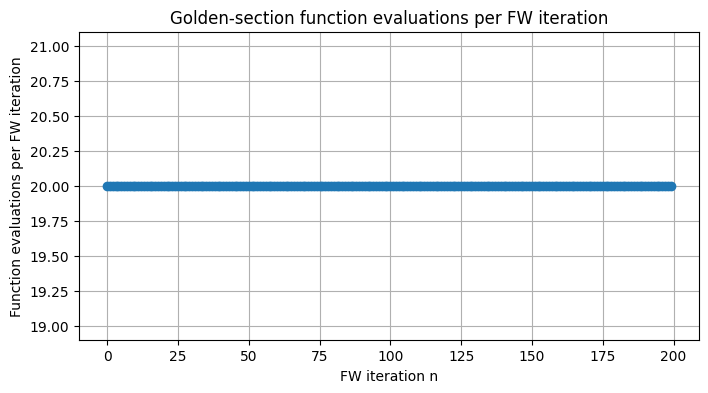

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_golden["fw_iter"], history_golden["function_evals"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Function evaluations per FW iteration")
plt.title("Golden-section function evaluations per FW iteration")
plt.grid(True)
plt.show()

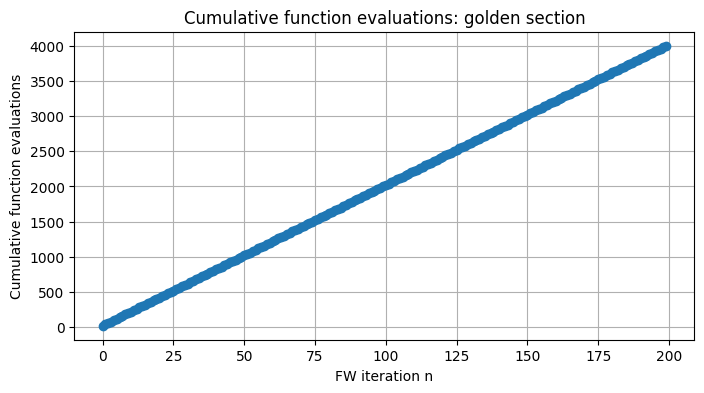

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_golden["fw_iter"], history_golden["total_function_evals"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Cumulative function evaluations")
plt.title("Cumulative function evaluations: golden section")
plt.grid(True)
plt.show()

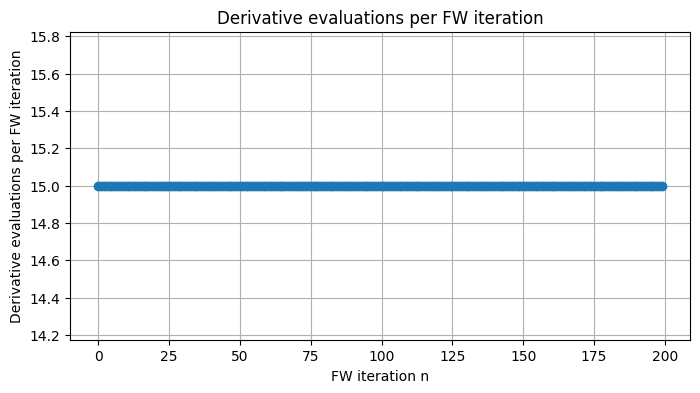

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_bisection["fw_iter"], history_bisection["derivative_evals"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Derivative evaluations per FW iteration")
plt.title("Derivative evaluations per FW iteration")
plt.grid(True)
plt.show()

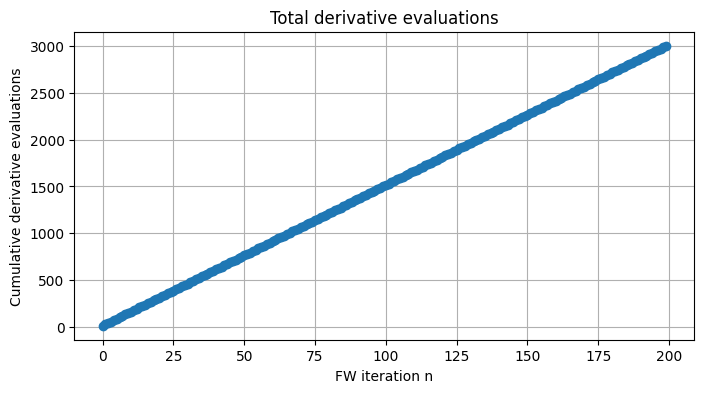

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_bisection["fw_iter"], history_bisection["total_derivative_evals"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Cumulative derivative evaluations")
plt.title("Total derivative evaluations")
plt.grid(True)
plt.show()

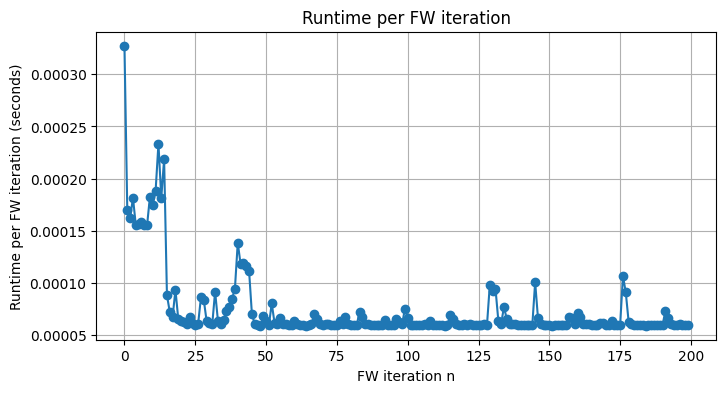

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_bisection["fw_iter"], history_bisection["iter_runtime"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Runtime per FW iteration (seconds)")
plt.title("Runtime per FW iteration for Bisection")
plt.grid(True)
plt.show()

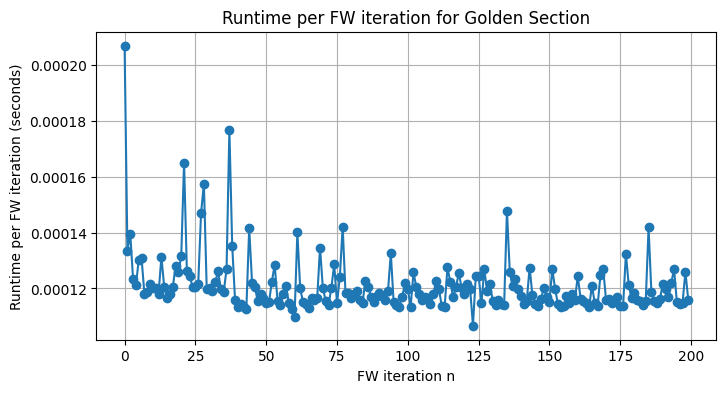

In [122]:
plt.figure(figsize=(8, 4))
plt.plot(history_golden["fw_iter"], history_golden["iter_runtime"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Runtime per FW iteration (seconds)")
plt.title("Runtime per FW iteration for Golden Section")
plt.grid(True)
plt.show()

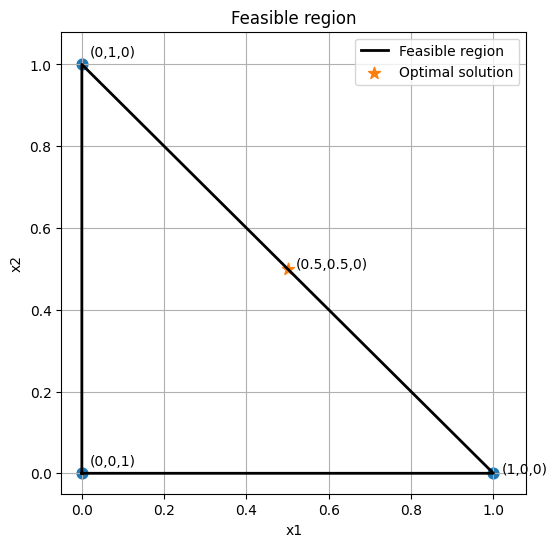

In [ ]:
plt.figure(figsize=(6, 6))

# feasible region boundary: x1 >= 0, x2 >= 0, x1 + x2 <= 1
triangle_x = [0, 1, 0, 0]
triangle_y = [0, 0, 1, 0]

plt.plot(triangle_x, triangle_y, "k-", linewidth=2, label="Feasible region")

# mark three vertices
plt.scatter([1, 0, 0], [0, 1, 0], s=60)
plt.text(1.02, 0.00, "(1,0,0)", fontsize=10)
plt.text(0.02, 1.02, "(0,1,0)", fontsize=10)
plt.text(0.02, 0.02, "(0,0,1)", fontsize=10)

# mark optimal solution
plt.scatter([0.5], [0.5], s=80, marker="*", label="Optimal solution")
plt.text(0.52, 0.50, "(0.5,0.5,0)", fontsize=10)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Feasible region")
plt.xlim(-0.05, 1.08)
plt.ylim(-0.05, 1.08)
plt.grid(True)
plt.legend()
plt.show()

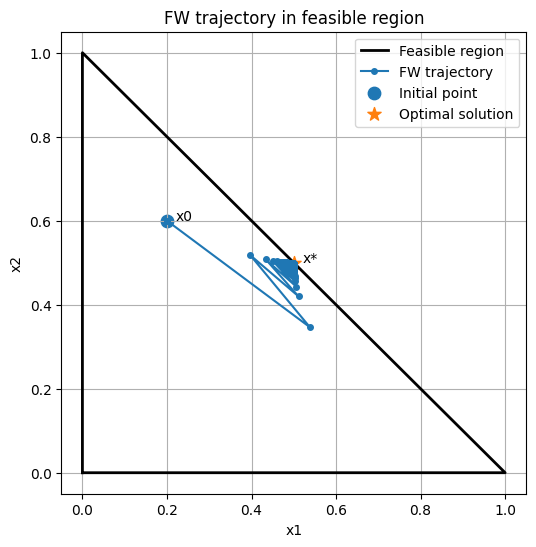

In [ ]:
plt.figure(figsize=(6, 6))

# feasible region
plt.plot([0, 1, 0, 0], [0, 0, 1, 0], "k-", linewidth=2, label="Feasible region")

# FW trajectory
plt.plot(
    history_bisection["x1"],
    history_bisection["x2"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="FW trajectory"
)

# initial point
plt.scatter([history_bisection.loc[0, "x1"]], [history_bisection.loc[0, "x2"]], s=80, label="Initial point")
plt.text(history_bisection.loc[0, "x1"] + 0.02, history_bisection.loc[0, "x2"], "x0", fontsize=10)

# optimal point
plt.scatter([0.5], [0.5], s=100, marker="*", label="Optimal solution")
plt.text(0.52, 0.50, "x*", fontsize=10)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("FW trajectory in feasible region")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

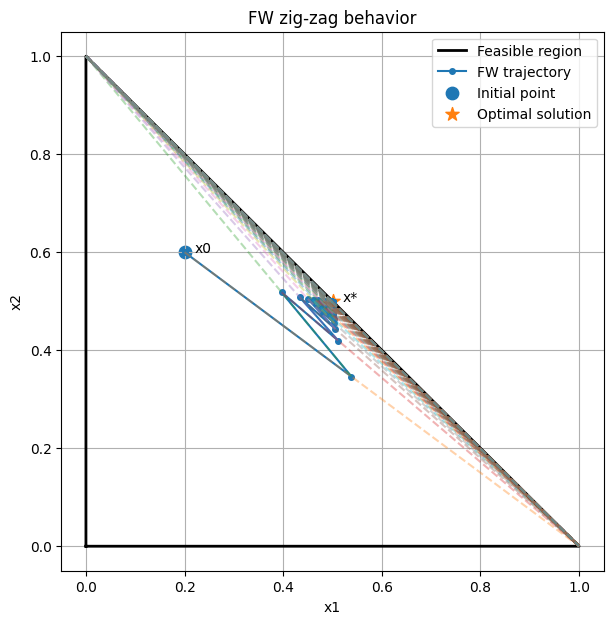

In [ ]:
plt.figure(figsize=(7, 7))

# feasible region boundary
plt.plot([0, 1, 0, 0], [0, 0, 1, 0], "k-", linewidth=2, label="Feasible region")

# FW trajectory
plt.plot(
    history_bisection["x1"],
    history_bisection["x2"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="FW trajectory"
)

# draw zig-zag search directions x^n -> y^n
for i in range(len(history_bisection)):
    x1_now = history_bisection.loc[i, "x1"]
    x2_now = history_bisection.loc[i, "x2"]
    y1_now = history_bisection.loc[i, "y1"]
    y2_now = history_bisection.loc[i, "y2"]

    plt.plot(
        [x1_now, y1_now],
        [x2_now, y2_now],
        linestyle="--",
        alpha=0.35
    )

# mark initial point
plt.scatter([history_bisection.loc[0, "x1"]], [history_bisection.loc[0, "x2"]], s=80, label="Initial point")
plt.text(history_bisection.loc[0, "x1"] + 0.02, history_bisection.loc[0, "x2"], "x0", fontsize=10)

# mark optimal solution
plt.scatter([0.5], [0.5], s=100, marker="*", label="Optimal solution")
plt.text(0.52, 0.50, "x*", fontsize=10)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("FW zig-zag behavior")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()